In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
%load_ext sql

In [8]:
df = pd.read_csv('df_clean.csv')

In [ ]:
# Filter for unresolved DNs (Late + Pending)
df_masalah = df[df['status_dn'].isin(['Late', 'Pending'])].copy()

print(df_masalah.shape)
print(df_masalah['status_dn'].value_counts())

(199, 13)
status_dn
Late       115
Pending     84
Name: count, dtype: int64


##### *Analysis is focused on the 199 unresolved DN transactions (Late + Pending) out of 683 total to answer the 4 defined business questions.*

### Question 1 — Which Institutions Have the Most Delayed DNs?

In [9]:
instansi_masalah = df_masalah.groupby(
    ['customer_name', 'customer_type']
)['dn_id'].count().reset_index()

instansi_masalah.columns = ['customer_name', 'customer_type', 'jumlah_masalah']
instansi_masalah = instansi_masalah.sort_values('jumlah_masalah', ascending=False)

print(instansi_masalah.head(10))

     customer_name customer_type  jumlah_masalah
23  Klinik Safitri        Klinik               7
67      RS Uyainah     RS Swasta               5
73       RS Wijaya     RS Swasta               5
36       RS Astuti     RS Swasta               5
30   Klinik Wasita        Klinik               5
35     RS Ardianto     RS Swasta               4
74    RS Wijayanti     RS Swasta               4
57      RS Permata     RS Swasta               4
49    RS Manullang     RS Swasta               4
47     RS Mahendra     RS Swasta               4


**Initial Findings:**  
Klinik Safitri has the highest number of unresolved DNs at 7, and the top 10 is largely dominated by private hospitals.

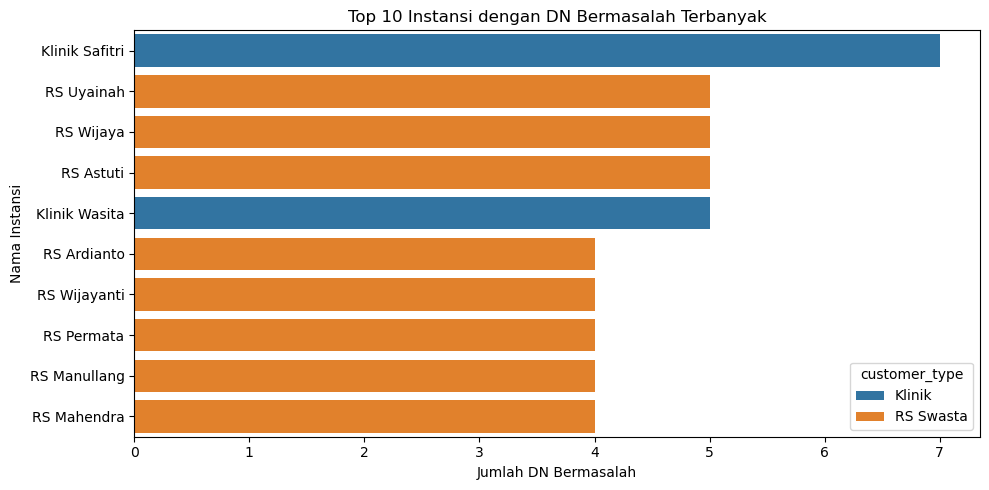

In [10]:
top10 = instansi_masalah.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='jumlah_masalah', y='customer_name', hue='customer_type')
plt.title('Top 10 Instansi dengan DN Bermasalah Terbanyak')
plt.xlabel('Jumlah DN Bermasalah')
plt.ylabel('Nama Instansi')
plt.tight_layout()
plt.show()

**Findings:**

| Institution | Unresolved DNs |
|---|---|
| Klinik Safitri | 7 (highest) |
| RS Uyainah, RS Wijaya, RS Astuti, Klinik Wasita | 5 each |
| Remaining top 10 | 4 each |

From the top 10: **8 are private hospitals (RS Swasta)**, 2 are clinics.

**Conclusion:**  
Klinik Safitri leads as the institution with the most unresolved DNs. Private hospitals making up 8 out of 10 spots isn't coincidental — it points to a systemic pattern within that customer segment that the collection team should address directly.

### Question 2 — What Is the Average DN Return Time from Healthcare Institutions?

In [12]:
df_returned = df[df['dn_return_date'].notnull()].copy()
df_returned['days_to_return'] = (
    pd.to_datetime(df_returned['dn_return_date']) - 
    pd.to_datetime(df_returned['delivery_date'])
).dt.days

In [13]:
rata_rata = df_returned.groupby('status_dn')['days_to_return'].mean().reset_index()
rata_rata.columns = ['status_dn', 'rata_rata_hari']
rata_rata['rata_rata_hari'] = rata_rata['rata_rata_hari'].round(1)

print(rata_rata)

  status_dn  rata_rata_hari
0      Late            29.9
1  Received             6.1


**Initial Findings:**  
Late DNs take almost 5x longer to be returned compared to on-time ones.

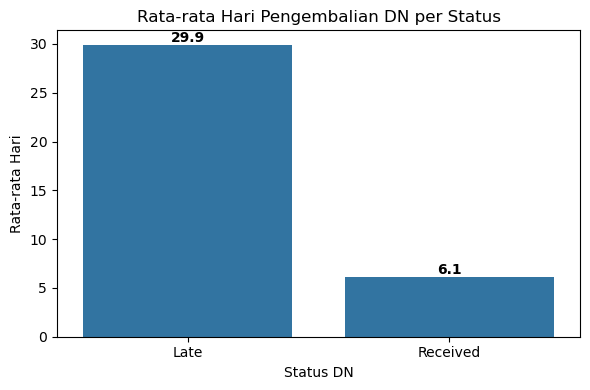

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=rata_rata, x='status_dn', y='rata_rata_hari')
plt.title('Rata-rata Hari Pengembalian DN per Status')
plt.xlabel('Status DN')
plt.ylabel('Rata-rata Hari')
for i, row in rata_rata.iterrows():
    plt.text(i, row['rata_rata_hari'] + 0.3,
             str(row['rata_rata_hari']),
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:**

| Status | Average Return Time |
|---|---|
| Received | 6.1 days (normal return) |
| Late | 29.9 days (delayed return) |

Late DNs take nearly 5x longer to be returned compared to on-time DNs.

**Conclusion:**  
There is a significant gap between on-time and late DN returns — delayed DNs aren't returned until nearly a month after delivery, far exceeding the normal 6-day window. This directly extends the time the company must wait before it can issue an invoice.

### Pertanyaan 3 — Di region mana yang sering telat mengembalikan DN?

In [10]:
region_masalah = df_masalah.groupby('region')['dn_id'].count().reset_index()
region_masalah.columns = ['region', 'jumlah_masalah']
region_masalah = region_masalah.sort_values('jumlah_masalah', ascending=False)

print(region_masalah)

            region  jumlah_masalah
3    Jakarta Barat              39
0           Bekasi              36
2            Depok              25
8        Tangerang              25
5  Jakarta Selatan              21
1            Bogor              15
6    Jakarta Timur              15
7    Jakarta Utara              13
4    Jakarta Pusat              10


**Temuan Awal**  
Jakarta Barat  → 39 DN bermasalah (tertinggi)  
Bekasi         → 36 DN bermasalah  
Depok          → 25 DN bermasalah  
Tangerang      → 25 DN bermasalah  
Jakarta Selatan→ 21 DN bermasalah  
Bogor          → 15 DN bermasalah  
Jakarta Timur  → 15 DN bermasalah  
Jakarta Utara  → 13 DN bermasalah  
Jakarta Pusat  → 10 DN bermasalah (terendah)

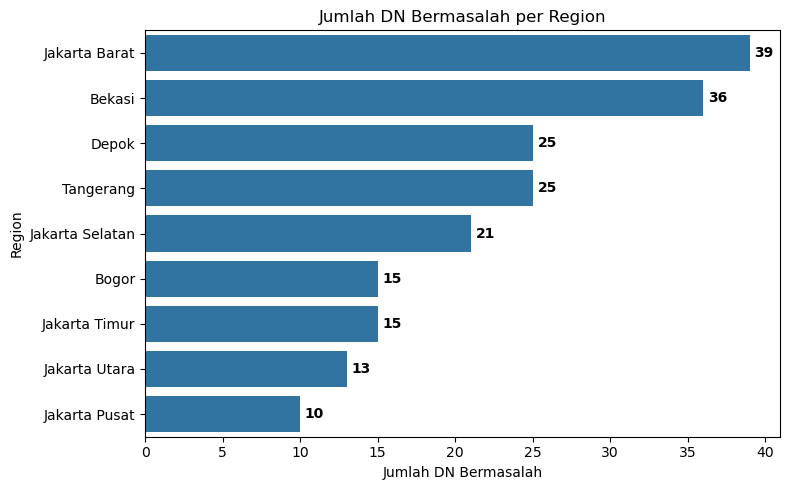

In [12]:
region_masalah = region_masalah.reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_masalah, x='jumlah_masalah', y='region')
plt.title('Jumlah DN Bermasalah per Region')
plt.xlabel('Jumlah DN Bermasalah')
plt.ylabel('Region')
for i, row in region_masalah.iterrows():
    plt.text(row['jumlah_masalah'] + 0.3, i,
             str(row['jumlah_masalah']),
             va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Pertanyaan 4 — Apa metode pengiriman yang digunakan pada region yang sering telat mengembalikan DN?

In [13]:
delivery_region = df_masalah.groupby(
    ['region', 'delivery_method']
)['dn_id'].count().reset_index()
delivery_region.columns = ['region', 'delivery_method', 'jumlah']
delivery_region = delivery_region.sort_values('jumlah', ascending=False)

print(delivery_region.head(10))

             region      delivery_method  jumlah
1            Bekasi  Third-Party Courier      29
6     Jakarta Barat             Internal      21
17        Tangerang  Third-Party Courier      19
7     Jakarta Barat  Third-Party Courier      18
5             Depok  Third-Party Courier      17
3             Bogor  Third-Party Courier      14
11  Jakarta Selatan  Third-Party Courier      11
10  Jakarta Selatan             Internal      10
14    Jakarta Utara             Internal       9
12    Jakarta Timur             Internal       9


**Temuan Awal**
- Bekasi         → Third-Party Courier: 29 (tertinggi!)
- Jakarta Barat  → Internal: 21
- Tangerang      → Third-Party Courier: 19
- Jakarta Barat  → Third-Party Courier: 18
- Depok          → Third-Party Courier: 17

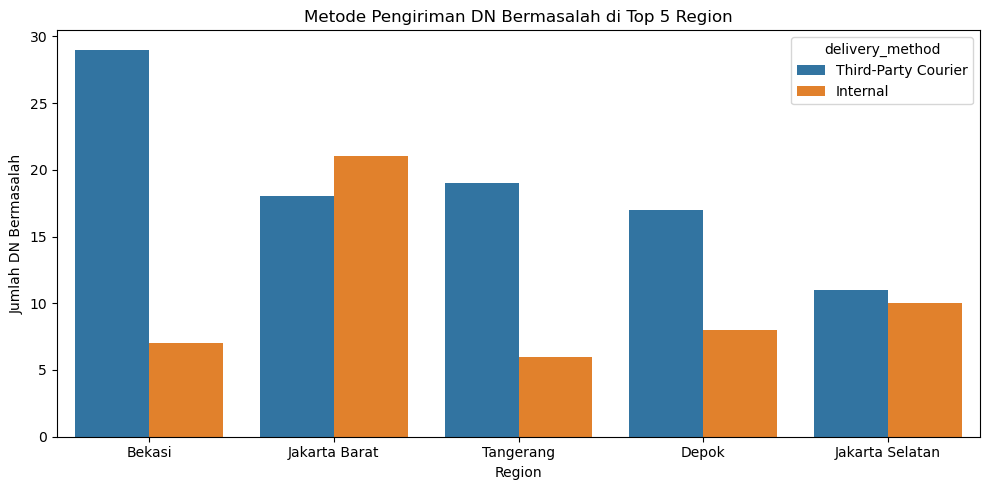

In [14]:
# Filter hanya top 5 region bermasalah
top5_region = ['Jakarta Barat', 'Bekasi', 'Depok', 'Tangerang', 'Jakarta Selatan']
delivery_top5 = delivery_region[delivery_region['region'].isin(top5_region)]

plt.figure(figsize=(10, 5))
sns.barplot(data=delivery_top5, x='region', y='jumlah', hue='delivery_method')
plt.title('Metode Pengiriman DN Bermasalah di Top 5 Region')
plt.xlabel('Region')
plt.ylabel('Jumlah DN Bermasalah')
plt.tight_layout()
plt.show()

**Temuan:**  
- Bekasi         → Third-Party Courier: 29, Internal: 7 (Third-Party Courier 4x lebih banyak bermasalah)  
- Jakarta Barat  → Internal: 21, Third-Party Courier: 18 (relatif seimbang, Internal sedikit lebih tinggi)  
- Tangerang      → Third-Party Courier: 19, Internal: 6 (Third-Party Courier dominan)  
- Depok          → Third-Party Courier: 17, Internal: 8 (Third-Party Courier dominan)  
- Jakarta Selatan→ Third-Party Courier: 11, Internal: 10 (hampir seimbang)

**Kesimpulan**  
Third-Party Courier mendominasi DN bermasalah di 4 dari 5 region teratas — terutama di Bekasi, Tangerang, dan Depok. Pengecualian di Jakarta Barat dimana Internal justru lebih tinggi, menunjukkan masalah di Jakarta Barat bukan semata karena metode pengiriman.

---

## Insight dan Rekomendasi  
  
### 1. Instansi Mana yang Sering Telat?  
#### Insight  
Klinik Safitri menjadi instansi dengan DN bermasalah terbanyak sepanjang tahun 2024, yaitu 7 kasus. Yang menarik, dari 10 instansi teratas, 8 diantaranya merupakan RS Swasta — ini bukan kebetulan, melainkan pola yang perlu diperhatikan perusahaan pada segmen tersebut.  
  
#### Recomendation  
Sales representative yang menangani instansi dengan riwayat DN bermasalah — terutama Klinik Safitri dan RS Swasta di top 10 — perlu melakukan follow up rutin minimal seminggu sekali untuk mengingatkan pengembalian DN sebelum jatuh tempo.
  
### 2. Berapa lama Rata-rata pengembalian DN dari instansi kesehatan?  
#### Insight  
DN yang dikembalikan tepat waktu rata-rata hanya butuh 6 hari — tapi untuk yang terlambat, angkanya melonjak hampir 5 kali lipat menjadi 29 hari. Artinya perusahaan harus menunggu hampir sebulan penuh sebelum bisa melakukan penagihan, padahal barang sudah dikirim sejak lama. Ini yang secara langsung memperlambat perputaran cash flow perusahaan.
  
#### Recomendation  
Perusahaan perlu menetapkan batas waktu maksimal pengembalian DN — misalnya 14 hari setelah barang diterima. Jika melewati batas itu, sales representative wajib melakukan eskalasi ke atasan agar bisa segera ditindaklanjuti sebelum semakin lama tertahan.

### 3. Di region mana yang sering telat mengembalikan DN?  
#### Insight
Jakarta Barat dan Bekasi menjadi dua region paling bermasalah dengan masing-masing 39 dan 36 kasus DN bermasalah. Kalau digabung, dua region ini saja sudah menyumbang 37.7% dari seluruh kasus — hampir 2 dari 5 DN bermasalah berasal dari wilayah ini. Menariknya, meski Jakarta Barat punya kasus terbanyak, Bekasi tidak jauh tertinggal dan justru punya pola masalah yang berbeda.

#### Recomendation
Perusahaan perlu menunjuk penanggung jawab khusus untuk Jakarta Barat dan Bekasi yang bertugas memantau dan menindaklanjuti DN yang belum kembali. Kedua region ini harus jadi prioritas utama sebelum memperluas pengawasan ke region lain.

### 4. Apa metode pengiriman yang digunakan pada region yang sering telat mengembalikan DN?  
#### Insight
Di sebagian besar region bermasalah, Third-Party Courier mendominasi kasus DN bermasalah — paling mencolok di Bekasi dimana 29 dari 36 kasus melibatkan kurir eksternal. Tapi Jakarta Barat justru jadi pengecualian yang menarik — Internal dan Third-Party Courier berkontribusi hampir sama besar (21 vs 18). Ini menunjukkan bahwa masalah di Jakarta Barat bukan soal siapa yang mengirim, tapi ada faktor lain yang belum teridentifikasi dari data ini.

#### Recomendation
Untuk Bekasi, Tangerang, dan Depok — perusahaan perlu mengevaluasi performa kurir Third-Party yang digunakan, apakah ada pola keterlambatan yang bisa diperbaiki dari sisi operasional pengiriman. Sementara untuk Jakarta Barat, evaluasi metode pengiriman saja tidak cukup — perlu investigasi lebih dalam, misalnya dari sisi karakteristik instansi atau prosedur penerimaan barang di wilayah tersebut.


---

### Insight dan Rekomendasi Utama
#### Insight
Sepanjang tahun 2024, hampir 1 dari 3 DN bermasalah — baik terlambat maupun belum kembali sama sekali. Jakarta Barat dan Bekasi menjadi dua region paling bermasalah dengan total 75 kasus, dimana DN yang terlambat rata-rata baru kembali setelah 30 hari — 5 kali lebih lama dari kondisi normal 6 hari. Menariknya, di Jakarta Barat masalah ini tidak bisa dikaitkan dengan metode pengiriman tertentu karena kurir internal dan third-party berkontribusi hampir sama besar, sementara di Bekasi, third-party courier mendominasi 80% kasus. Di level instansi, RS Swasta mendominasi top 10 dengan 8 dari 10 instansi bermasalah, dan Klinik Safitri menjadi instansi dengan DN bermasalah terbanyak sepanjang tahun ini.

#### Recomendation
Pertama, perusahaan perlu menetapkan batas waktu maksimal pengembalian DN — misalnya 14 hari setelah barang diterima — sebagai standar operasional yang berlaku untuk semua instansi. Kedua, bentuk tim pengawas khusus yang diprioritaskan di Jakarta Barat dan Bekasi, dengan tugas memantau DN yang mendekati atau melewati batas waktu tersebut. Tim ini bekerja sama dengan sales representative untuk melakukan follow up langsung ke instansi minimal seminggu sekali. Ketiga, evaluasi menyeluruh perlu dilakukan terhadap metode pengiriman di region bermasalah — khususnya performa Third-Party Courier di Bekasi, Tangerang, dan Depok. Sementara untuk Jakarta Barat, evaluasi perlu diperluas ke faktor lain di luar metode pengiriman, mengingat kedua metode berkontribusi hampir sama besar di region tersebut.